In [30]:

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report 

# Import from our custom modules in the src/ folder
from NN.features import clean_and_engineer, prepare_model_data, FAT_TAIL_FEATURES
from NN.dataset import FinancialNeedsDataset
from NN.model import MultiTaskNeedsMLP
from NN.train import train_multitask_model

print("Setup complete. Custom modules loaded successfully.")



Setup complete. Custom modules loaded successfully.


In [31]:
import joblib
from pathlib import Path

# 1. Load + engineer
df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Needs')
df_engineered = clean_and_engineer(df)

# 2. Strict 3-way split with fitted scalers returned (fix #1, #2)
(X_train, X_val, X_test,
 y_train, y_val, y_test,
 feature_cols, qt, rs) = prepare_model_data(df_engineered)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# 3. Persist scalers so inference in production uses the exact same transform (fix #2)
Path('artifacts').mkdir(exist_ok=True)
joblib.dump({'qt': qt, 'rs': rs, 'feature_cols': feature_cols},
            'artifacts/preprocessors.joblib')

# 4. Continuous mask for safe augmentation (fix #3)
#    Exclude ALL discrete / ordinal / bounded-category columns - noise on them
#    creates impossible users (e.g. 2.3 family members).
discrete_features = {
    'Gender', 'FamilyMembers', 'FinancialEducation',
    'LifeStage_working', 'LifeStage_retired',
}
continuous_mask = [col not in discrete_features for col in feature_cols]
print(f"Augmenting {sum(continuous_mask)}/{len(feature_cols)} features with Gaussian noise.")

# 5. PyTorch datasets - augmentation on TRAIN only
#train_dataset = FinancialNeedsDataset(X_train, y_train, augment=True,
#                                      noise_std=0.05, continuous_mask=continuous_mask)
train_dataset = FinancialNeedsDataset(X_train, y_train, augment=False) #best model was trained without augmentation
                                        

val_dataset   = FinancialNeedsDataset(X_val,   y_val,   augment=False)
test_dataset  = FinancialNeedsDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

Train: (3200, 20) | Val: (800, 20) | Test: (1000, 20)
Augmenting 15/20 features with Gaussian noise.


In [32]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score
import time

print("--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---\n")

def evaluate_svm_baseline(X_tr, y_tr, X_v, y_v, target_name):
    print(f"Target: {target_name}")
    print("="*40)
    
    start_time = time.time()
    
    # Support Vector Machine
    # class_weight='balanced' is crucial for the imbalanced Income target
    svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
    svm_model.fit(X_tr, y_tr)
    
    svm_preds = svm_model.predict_proba(X_v)[:, 1]
    svm_pred_class = svm_model.predict(X_v)
    
    auc = roc_auc_score(y_v, svm_preds)
    f1 = f1_score(y_v, svm_pred_class)
    
    print(f"SVM ROC-AUC     : {auc:.4f}")
    print(f"SVM F1-Score    : {f1:.4f}")
    print(f"Training Time   : {time.time() - start_time:.2f} seconds\n")
    
    return svm_model

# Evaluate Income
svm_inc = evaluate_svm_baseline(
    X_train, y_train['IncomeInvestment'], 
    X_val, y_val['IncomeInvestment'], 
    "Income Investment"
)

# Evaluate Accumulation
svm_acc = evaluate_svm_baseline(
    X_train, y_train['AccumulationInvestment'], 
    X_val, y_val['AccumulationInvestment'], 
    "Accumulation Investment"
)

--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---

Target: Income Investment
SVM ROC-AUC     : 0.7294
SVM F1-Score    : 0.6335
Training Time   : 2.22 seconds

Target: Accumulation Investment
SVM ROC-AUC     : 0.8536
SVM F1-Score    : 0.7817
Training Time   : 2.04 seconds



In [33]:
import torch.nn as nn
import torch.nn.functional as F

# 1. Define the Single-Task Architecture (Exact same capacity as one branch of the Multi-Task model)
class SingleTaskMLP(nn.Module):
    def __init__(self, in_dim, trunk=(64, 32), head=(16,), p=0.25):
        super().__init__()
        layers, d = [], in_dim
        
        # Trunk
        for h in trunk:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        # Head
        for h in head:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        layers += [nn.Linear(d, 1)] # Single output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

# 2. Quick Training Loop for Single-Task
def train_single_task(target_idx, train_loader, val_loader, in_dim, pos_weight, epochs=40):
    model = SingleTaskMLP(in_dim=in_dim)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    best_auc = 0
    for epoch in range(epochs):
        model.train()
        for X_batch, y_inc, y_acc in train_loader:
            optimizer.zero_grad()
            
            # Select target: target_idx 0 is Income, 1 is Accumulation
            targets = y_inc if target_idx == 0 else y_acc
            logits = model(X_batch)
            
            loss = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        val_preds, val_targs = [], []
        with torch.no_grad():
            for X_batch, y_inc, y_acc in val_loader:
                targets = y_inc if target_idx == 0 else y_acc
                logits = model(X_batch)
                val_preds.extend(torch.sigmoid(logits).numpy())
                val_targs.extend(targets.numpy())
                
        auc = roc_auc_score(val_targs, val_preds)
        if auc > best_auc:
            best_auc = auc
            
    return best_auc

# 3. Execute Single-Task Training
print("--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---")

# Weights (Calculated dynamically)
w_inc = torch.tensor((len(y_train) - y_train['IncomeInvestment'].sum()) / y_train['IncomeInvestment'].sum())
w_acc = torch.tensor((len(y_train) - y_train['AccumulationInvestment'].sum()) / y_train['AccumulationInvestment'].sum())

auc_inc_single = train_single_task(0, train_loader, val_loader, len(feature_cols), w_inc)
auc_acc_single = train_single_task(1, train_loader, val_loader, len(feature_cols), w_acc)

print(f"Single-Task NN | Income ROC-AUC       : {auc_inc_single:.4f}")
print(f"Single-Task NN | Accumulation ROC-AUC : {auc_acc_single:.4f}\n")

--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---
Single-Task NN | Income ROC-AUC       : 0.7404
Single-Task NN | Accumulation ROC-AUC : 0.8710



In [34]:
# --- Class weights from TRAIN ---
num_acc_pos = y_train['AccumulationInvestment'].sum()
num_inc_pos = y_train['IncomeInvestment'].sum()
w_a = torch.tensor((len(y_train) - num_acc_pos) / num_acc_pos, dtype=torch.float32)
w_i = torch.tensor((len(y_train) - num_inc_pos) / num_inc_pos, dtype=torch.float32)
print(f"Class weight Accumulation: {w_a.item():.3f} | Income: {w_i.item():.3f}")

# --- DYNAMIC joint prior from TRAIN data (fix #4) ---
# Empirical probabilities of [Neither, IncomeOnly, AccumOnly, Both]
ya = y_train['AccumulationInvestment'].values
yi = y_train['IncomeInvestment'].values
joint_prior = torch.tensor([
    ((1 - ya) * (1 - yi)).mean(),   # Neither
    ((1 - ya) *      yi ).mean(),   # Income only
    (     ya  * (1 - yi)).mean(),   # Accumulation only
    (     ya  *      yi ).mean(),   # Both
], dtype=torch.float32)
print(f"Empirical joint prior (Neither, IncOnly, AccOnly, Both): "
      f"{joint_prior.numpy().round(3)}")

# --- Model ---
model = MultiTaskNeedsMLP(in_dim=len(feature_cols), trunk=(64, 32), head=(16,), p=0.25)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Class weight Accumulation: 0.949 | Income: 1.606
Empirical joint prior (Neither, IncOnly, AccOnly, Both): [0.303 0.184 0.313 0.2  ]


## Hyperparameter tuning with Optuna

The RF baseline benefits from explicit Bayesian optimization of its
hyperparameters (TPE sampler, 20 trials). To make our NN comparison fair,
we run the same kind of search over:

- learning rate, weight decay
- dropout probability
- trunk widths (depth × width)
- KL penalty weight (`lam`)
- batch size

Objective: mean PR-AUC on validation, averaged across both heads. We cap each
trial at 40 epochs with patience=10 to keep the whole search under 15 minutes.

Set `RUN_OPTUNA = True` to execute the search; set it to `False` to skip and
use the hand-picked defaults from the original cell 4.


In [35]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import average_precision_score

RUN_OPTUNA = True      # flip to False to keep hand-picked defaults
N_TRIALS = 50          # ~12-15 min total on CPU

def objective(trial):
    # Search space
    lr          = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd          = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    dropout_p   = trial.suggest_float('dropout', 0.10, 0.45)
    trunk_w1    = trial.suggest_categorical('trunk_w1', [32, 64, 96, 128])
    trunk_w2    = trial.suggest_categorical('trunk_w2', [16, 32, 48, 64])
    head_w      = trial.suggest_categorical('head_w', [8, 16, 24, 32])
    lam         = trial.suggest_float('lam', 0.0, 0.30)
    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Keep augmentation OFF - ablation showed it hurts
    tr_ds = FinancialNeedsDataset(X_train, y_train, augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)

    torch.manual_seed(42)
    m = MultiTaskNeedsMLP(in_dim=len(feature_cols),
                           trunk=(trunk_w1, trunk_w2),
                           head=(head_w,),
                           p=dropout_p)
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)

    try:
        m, _ = train_multitask_model(m, tr_ld, val_loader, opt,
                                      w_a, w_i, joint_prior,
                                      epochs=40, patience=10, lam=lam)
    except Exception as e:
        # Degenerate config (e.g. NaN loss) -> prune
        raise optuna.TrialPruned()

    # Score: mean PR-AUC on val (same signal train loop already uses)
    m.eval()
    pa, pi, ya, yi = [], [], [], []
    with torch.no_grad():
        for X_batch, y_inc_b, y_acc_b in val_loader:
            la, li = m(X_batch)
            pa.extend(torch.sigmoid(la).numpy())
            pi.extend(torch.sigmoid(li).numpy())
            ya.extend(y_acc_b.numpy())
            yi.extend(y_inc_b.numpy())
    return 0.5 * (average_precision_score(ya, pa) +
                  average_precision_score(yi, pi))


if RUN_OPTUNA:
    # Silence Optuna's per-trial logging; keep only the summary below
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(direction='maximize',
                                 sampler=TPESampler(seed=42))
    print(f"Running Optuna with {N_TRIALS} trials...")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"\nBest mean PR-AUC: {study.best_value:.4f}")
    print(f"Best params:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    BEST = study.best_params
else:
    # Hand-picked defaults (what cell 4 originally used)
    BEST = dict(lr=1e-3, weight_decay=1e-4, dropout=0.25,
                trunk_w1=64, trunk_w2=32, head_w=16,
                lam=0.15, batch_size=64)
    print("Skipped Optuna, using defaults:", BEST)

# Rebuild the final model and DataLoader with the winning config
train_dataset = FinancialNeedsDataset(X_train, y_train, augment=False)
train_loader  = DataLoader(train_dataset, batch_size=BEST['batch_size'], shuffle=True)

model = MultiTaskNeedsMLP(in_dim=len(feature_cols),
                           trunk=(BEST['trunk_w1'], BEST['trunk_w2']),
                           head=(BEST['head_w'],),
                           p=BEST['dropout'])
optimizer = optim.AdamW(model.parameters(),
                         lr=BEST['lr'], weight_decay=BEST['weight_decay'])

# Persist best hyperparameters alongside the model artifacts
joblib.dump(BEST, 'artifacts/best_hyperparams.joblib')
print("\nFinal model ready to train with tuned hyperparameters.")

Running Optuna with 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 000 | Loss: 1.5354 | ROC-AUC (Acc/Inc): 0.671/0.685 | PR-AUC (Acc/Inc): 0.653/0.632
Epoch 010 | Loss: 1.3077 | ROC-AUC (Acc/Inc): 0.806/0.710 | PR-AUC (Acc/Inc): 0.827/0.698
Epoch 020 | Loss: 1.2500 | ROC-AUC (Acc/Inc): 0.825/0.717 | PR-AUC (Acc/Inc): 0.862/0.703
Epoch 030 | Loss: 1.2272 | ROC-AUC (Acc/Inc): 0.841/0.724 | PR-AUC (Acc/Inc): 0.882/0.708
Epoch 000 | Loss: 1.3959 | ROC-AUC (Acc/Inc): 0.777/0.705 | PR-AUC (Acc/Inc): 0.772/0.692
Epoch 010 | Loss: 1.1498 | ROC-AUC (Acc/Inc): 0.856/0.724 | PR-AUC (Acc/Inc): 0.892/0.708
Epoch 020 | Loss: 1.1168 | ROC-AUC (Acc/Inc): 0.859/0.736 | PR-AUC (Acc/Inc): 0.895/0.714
Epoch 030 | Loss: 1.1207 | ROC-AUC (Acc/Inc): 0.860/0.733 | PR-AUC (Acc/Inc): 0.896/0.713
Epoch 000 | Loss: 1.4215 | ROC-AUC (Acc/Inc): 0.805/0.700 | PR-AUC (Acc/Inc): 0.802/0.688
Epoch 010 | Loss: 1.1366 | ROC-AUC (Acc/Inc): 0.861/0.736 | PR-AUC (Acc/Inc): 0.896/0.713
Epoch 020 | Loss: 1.1185 | ROC-AUC (Acc/Inc): 0.865/0.745 | PR-AUC (Acc/Inc): 0.898/0.721
Epoch 030 

In [36]:
print("Starting Multi-Task Training...\n")

best_model, val_auc = train_multitask_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer, 
    w_a=w_a, 
    w_i=w_i, 
    joint_prior=joint_prior, 
    epochs=150, 
    patience=20, 
    lam=BEST['lam']  # tuned by Optuna (falls back to 0.15 if RUN_OPTUNA=False)
)

print(f"\nTraining Complete! Best Validation AUC (Mean): {val_auc:.4f}")

Starting Multi-Task Training...

Epoch 000 | Loss: 1.3415 | ROC-AUC (Acc/Inc): 0.797/0.713 | PR-AUC (Acc/Inc): 0.784/0.697
Epoch 010 | Loss: 1.1062 | ROC-AUC (Acc/Inc): 0.864/0.720 | PR-AUC (Acc/Inc): 0.898/0.705
Epoch 020 | Loss: 1.0965 | ROC-AUC (Acc/Inc): 0.867/0.727 | PR-AUC (Acc/Inc): 0.899/0.715
Epoch 030 | Loss: 1.0807 | ROC-AUC (Acc/Inc): 0.861/0.726 | PR-AUC (Acc/Inc): 0.896/0.714
Epoch 040 | Loss: 1.0655 | ROC-AUC (Acc/Inc): 0.871/0.732 | PR-AUC (Acc/Inc): 0.903/0.719
Epoch 050 | Loss: 1.0564 | ROC-AUC (Acc/Inc): 0.873/0.731 | PR-AUC (Acc/Inc): 0.906/0.718
Epoch 060 | Loss: 1.0462 | ROC-AUC (Acc/Inc): 0.870/0.731 | PR-AUC (Acc/Inc): 0.902/0.720
Epoch 070 | Loss: 1.0364 | ROC-AUC (Acc/Inc): 0.866/0.740 | PR-AUC (Acc/Inc): 0.900/0.727
Epoch 080 | Loss: 1.0083 | ROC-AUC (Acc/Inc): 0.870/0.734 | PR-AUC (Acc/Inc): 0.904/0.727

Early stopping triggered at epoch 83. Restoring best weights.

Training Complete! Best Validation AUC (Mean): 0.8201


In [37]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, brier_score_loss

def get_raw_probs(model, loader):
    """Returns (p_acc, p_inc, y_acc, y_inc) as flat numpy arrays."""
    model.eval()
    pa, pi, ya, yi = [], [], [], []
    with torch.no_grad():
        for X_batch, y_inc, y_acc in loader:
            la, li = model(X_batch)
            pa.extend(torch.sigmoid(la).numpy())
            pi.extend(torch.sigmoid(li).numpy())
            ya.extend(y_acc.numpy())
            yi.extend(y_inc.numpy())
    return np.array(pa), np.array(pi), np.array(ya), np.array(yi)

# 1) Raw probabilities on VAL (for fitting calibration + tuning thresholds)
p_acc_val, p_inc_val, y_acc_val, y_inc_val = get_raw_probs(model, val_loader)

# 2) Platt scaling with per-head fallback
#    Platt = 2-parameter logistic fit on (p_raw -> y). Far less overfit-prone
#    on small val sets than isotonic (which is a step function with up to
#    N-1 knots). If calibration still hurts Brier on val, we skip it per head.
def fit_calibrator(p_val, y_val, name):
    lr = LogisticRegression(C=1.0, solver='liblinear')
    lr.fit(p_val.reshape(-1, 1), y_val)
    calibrated = lambda p: lr.predict_proba(p.reshape(-1, 1))[:, 1]

    brier_raw = brier_score_loss(y_val, p_val)
    brier_cal = brier_score_loss(y_val, calibrated(p_val))
    if brier_cal < brier_raw:
        print(f"  {name}: calibration KEPT  (Brier {brier_raw:.4f} -> {brier_cal:.4f})")
        return calibrated, lr, True
    else:
        print(f"  {name}: calibration SKIPPED (Brier {brier_raw:.4f} -> {brier_cal:.4f}, would hurt)")
        return (lambda p: p), lr, False

print("Fitting calibrators on validation set:")
cal_acc, lr_acc, acc_kept = fit_calibrator(p_acc_val, y_acc_val, "Accumulation")
cal_inc, lr_inc, inc_kept = fit_calibrator(p_inc_val, y_inc_val, "Income      ")

p_acc_val_cal = cal_acc(p_acc_val)
p_inc_val_cal = cal_inc(p_inc_val)

# 3) Threshold sweep on calibrated VAL probabilities - pick F1-maximizer per head
def best_threshold(y_true, p, grid=np.linspace(0.05, 0.95, 181)):
    scores = [f1_score(y_true, p > t) for t in grid]
    best_idx = int(np.argmax(scores))
    return float(grid[best_idx]), float(scores[best_idx])

thr_acc, f1_acc_val = best_threshold(y_acc_val, p_acc_val_cal)
thr_inc, f1_inc_val = best_threshold(y_inc_val, p_inc_val_cal)
print(f"\nOptimal thresholds | Accum: {thr_acc:.3f} (F1={f1_acc_val:.3f}) "
      f"| Income: {thr_inc:.3f} (F1={f1_inc_val:.3f})")

# 4) FINAL evaluation on TEST using VAL-tuned calibrators + thresholds (fix #5)
p_acc_te, p_inc_te, y_acc_te, y_inc_te = get_raw_probs(model, test_loader)
p_acc_te_cal = cal_acc(p_acc_te)
p_inc_te_cal = cal_inc(p_inc_te)

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report)
print("\n=== HOLD-OUT TEST RESULTS (calibrated + tuned) ===")
for name, y_te, p_raw, p_cal, thr in [
    ('Accumulation', y_acc_te, p_acc_te, p_acc_te_cal, thr_acc),
    ('Income',       y_inc_te, p_inc_te, p_inc_te_cal, thr_inc),
]:
    print(f"\n--- {name} ---")
    print(f"ROC-AUC:        {roc_auc_score(y_te, p_cal):.4f}")
    print(f"PR-AUC:         {average_precision_score(y_te, p_cal):.4f}")
    print(f"Brier (raw):    {brier_score_loss(y_te, p_raw):.4f}")
    print(f"Brier (calib):  {brier_score_loss(y_te, p_cal):.4f}   <- lower = better calibrated")
    print(classification_report(y_te, (p_cal > thr).astype(int), digits=3))

# Persist: store the sklearn LR objects + kept flags so we can rebuild lambdas on load
joblib.dump({'lr_acc': lr_acc, 'acc_kept': acc_kept,
             'lr_inc': lr_inc, 'inc_kept': inc_kept,
             'thr_acc': thr_acc, 'thr_inc': thr_inc},
            'artifacts/calibration.joblib')
torch.save(model.state_dict(), 'artifacts/model_weights.pt')


Fitting calibrators on validation set:
  Accumulation: calibration KEPT  (Brier 0.1353 -> 0.1349)
  Income      : calibration KEPT  (Brier 0.1833 -> 0.1775)

Optimal thresholds | Accum: 0.480 (F1=0.809) | Income: 0.405 (F1=0.651)

=== HOLD-OUT TEST RESULTS (calibrated + tuned) ===

--- Accumulation ---
ROC-AUC:        0.8504
PR-AUC:         0.8911
Brier (raw):    0.1462
Brier (calib):  0.1486   <- lower = better calibrated
              precision    recall  f1-score   support

         0.0      0.763     0.832     0.796       487
         1.0      0.825     0.754     0.788       513

    accuracy                          0.792      1000
   macro avg      0.794     0.793     0.792      1000
weighted avg      0.795     0.792     0.792      1000


--- Income ---
ROC-AUC:        0.7926
PR-AUC:         0.7856
Brier (raw):    0.1616
Brier (calib):  0.1589   <- lower = better calibrated
              precision    recall  f1-score   support

         0.0      0.784     0.896     0.837       61

In [38]:
import numpy as np
from pathlib import Path
Path('compare_preds').mkdir(exist_ok=True)
 
# Labels: save once. These are the shared ground truth for all three models.
np.save('compare_preds/y_acc_test.npy', y_acc_te)
np.save('compare_preds/y_inc_test.npy', y_inc_te)
 
# MTL probabilities (calibrated)
np.save('compare_preds/mtl_p_acc_test.npy', p_acc_te_cal)
np.save('compare_preds/mtl_p_inc_test.npy', p_inc_te_cal)
print("MTL predictions saved.")

MTL predictions saved.


Catalogue: 7 accumulation / 4 income products
  Accum  risk range: [0.270, 0.880]
  Income risk range: [0.120, 0.440]

Thresholds used  : Accum=0.480 | Income=0.405
Need Accumulation:  2287 clients (45.7%)
Need Income      :  1552 clients (31.0%)

First 10 personalized recommendations:


,ClientID,ClientRisk,P_Accum,P_Income,NeedAccum,NeedIncome,Rec_Accum_ID,Rec_Accum_Risk,Rec_Income_ID,Rec_Income_Risk
0,1,0.2334,0.9460,0.2450,True,False,NaN,NaN,NaN,NaN
1,2,0.1709,0.3280,0.7891,False,True,NaN,NaN,10.0,0.13
2,3,0.2497,0.1878,0.3193,False,False,NaN,NaN,NaN,NaN
3,4,0.6546,0.9376,0.8144,True,True,1.0,0.55,4.0,0.44
4,5,0.3490,0.2240,0.2390,False,False,NaN,NaN,NaN,NaN
5,6,0.5144,0.9454,0.2017,True,False,8.0,0.48,NaN,NaN
6,7,0.3783,0.9464,0.2889,True,False,6.0,0.36,NaN,NaN
7,8,0.2161,0.9474,0.2330,True,False,NaN,NaN,NaN,NaN
8,9,0.1775,0.2031,0.8092,False,True,NaN,NaN,10.0,0.13
9,10,0.4542,0.7252,0.8227,True,True,5.0,0.41,4.0,0.44



=== COVERAGE DECOMPOSITION ===
                                               Segment  Clients  Pct (%)
                   No need predicted (correct silence)     1810     36.2
                   At least one recommendation emitted     2636     52.7
 Accumulation gap (need flagged, no compliant product)      585     11.7
Income gap        (need flagged, no compliant product)       93      1.9

Note: 'gap' rows are a PRODUCT-LINE signal, not a model failure - the
model identified a need, but the catalogue has no compliant match.


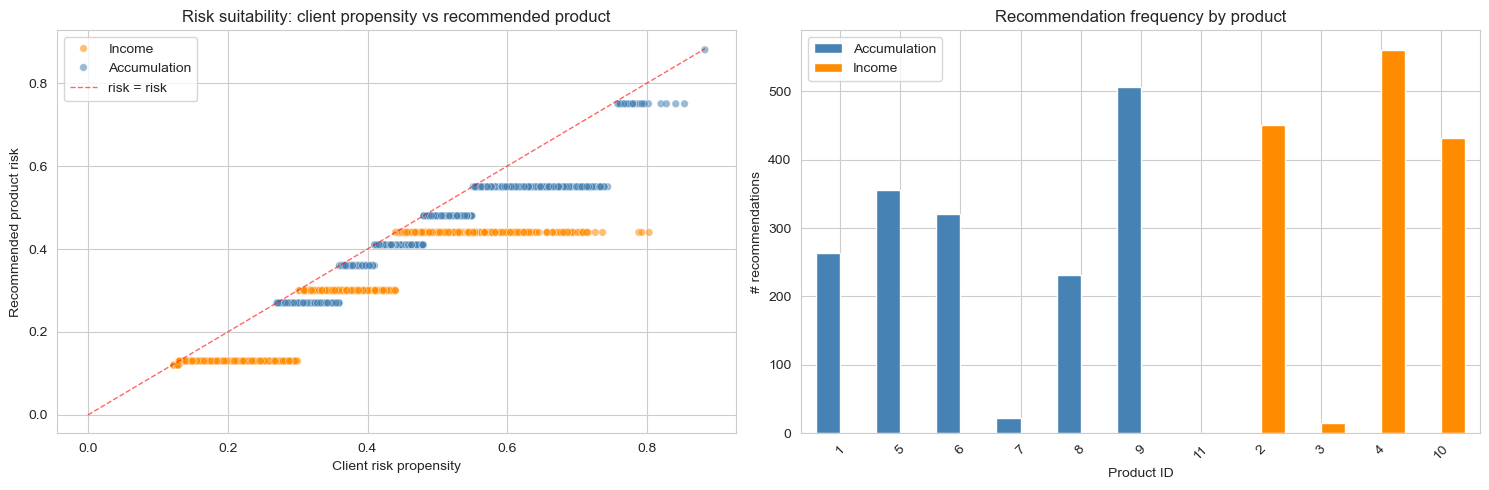


=== TOP-3 MOST RECOMMENDED (Accumulation) ===
  ProductID 9    | Risk 0.270 | recommended to 506 clients
  ProductID 5    | Risk 0.410 | recommended to 356 clients
  ProductID 6    | Risk 0.360 | recommended to 321 clients

=== TOP-3 MOST RECOMMENDED (Income) ===
  ProductID 4    | Risk 0.440 | recommended to 561 clients
  ProductID 2    | Risk 0.300 | recommended to 451 clients
  ProductID 10   | Risk 0.130 | recommended to 432 clients

Saved -> artifacts/recommendations.csv


In [39]:
# =============================================================================
# CELL 9 - PERSONALIZED RECOMMENDATIONS
# -----------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---- 1) Real product catalogue (no synthetic Utility column) ---------------
products_df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Products')

accum_products  = products_df[products_df['Type'] == 1].reset_index(drop=True)
income_products = products_df[products_df['Type'] == 0].reset_index(drop=True)

print(f"Catalogue: {len(accum_products)} accumulation / "
      f"{len(income_products)} income products")
print(f"  Accum  risk range: [{accum_products['Risk'].min():.3f}, "
      f"{accum_products['Risk'].max():.3f}]")
print(f"  Income risk range: [{income_products['Risk'].min():.3f}, "
      f"{income_products['Risk'].max():.3f}]")

# ---- 2) Score every client with the frozen scalers + trained model ---------
#  No refitting here - this is pure inference.
X_full = df_engineered[feature_cols].copy()
X_full[FAT_TAIL_FEATURES] = qt.transform(X_full[FAT_TAIL_FEATURES])
std_cols = [c for c in feature_cols if c not in FAT_TAIL_FEATURES]
X_full[std_cols] = rs.transform(X_full[std_cols])

model.eval()
with torch.no_grad():
    Xt = torch.tensor(X_full.values, dtype=torch.float32)
    logits_a, logits_i = model(Xt)
    p_acc_all = cal_acc(torch.sigmoid(logits_a).numpy())
    p_inc_all = cal_inc(torch.sigmoid(logits_i).numpy())

# Per-head tuned thresholds (from cell 8) - NOT 0.5
need_acc = p_acc_all >= thr_acc
need_inc = p_inc_all >= thr_inc

# Real risk tolerance, raw units (products are also in raw units)
client_risks = df_engineered['RiskPropensity'].values

print(f"\nThresholds used  : Accum={thr_acc:.3f} | Income={thr_inc:.3f}")
print(f"Need Accumulation: {need_acc.sum():>5} clients ({need_acc.mean()*100:.1f}%)")
print(f"Need Income      : {need_inc.sum():>5} clients ({need_inc.mean()*100:.1f}%)")

# ---- 3) Matching rule (professor's approach) -------------------------------
def match_best_product(client_risk: float, catalogue: pd.DataFrame):
    """
    Among products with Risk <= client_risk, return the one with the highest
    Risk (id, risk). Returns (None, None) if no product fits -> catalogue gap.
    """
    eligible = catalogue[catalogue['Risk'] <= client_risk + 1e-9]
    if eligible.empty:
        return None, None
    best = eligible.loc[eligible['Risk'].idxmax()]
    return int(best['IDProduct']), float(best['Risk'])

# ---- 4) Generate recommendations for both heads ----------------------------
rows = []
for i in range(len(df_engineered)):
    cr = client_risks[i]

    rec_a_id, rec_a_risk = (None, None)
    if need_acc[i]:
        rec_a_id, rec_a_risk = match_best_product(cr, accum_products)

    rec_i_id, rec_i_risk = (None, None)
    if need_inc[i]:
        rec_i_id, rec_i_risk = match_best_product(cr, income_products)

    rows.append({
        'ClientID':        i + 1,
        'ClientRisk':      round(cr, 4),
        'P_Accum':         round(float(p_acc_all[i]), 4),
        'P_Income':        round(float(p_inc_all[i]), 4),
        'NeedAccum':       bool(need_acc[i]),
        'NeedIncome':      bool(need_inc[i]),
        'Rec_Accum_ID':    rec_a_id,
        'Rec_Accum_Risk':  rec_a_risk,
        'Rec_Income_ID':   rec_i_id,
        'Rec_Income_Risk': rec_i_risk,
    })

nba = pd.DataFrame(rows)

print("\nFirst 10 personalized recommendations:")
display(nba.head(10))

# ---- 5) Coverage decomposition (per head) ----------------------------------
covered_acc = nba['Rec_Accum_ID'].notna()
covered_inc = nba['Rec_Income_ID'].notna()
covered_any = covered_acc | covered_inc

gap_acc = nba['NeedAccum']  & ~covered_acc    # need flagged, no compliant product
gap_inc = nba['NeedIncome'] & ~covered_inc
silent  = ~nba['NeedAccum'] & ~nba['NeedIncome']

summary = pd.DataFrame({
    'Segment': [
        'No need predicted (correct silence)',
        'At least one recommendation emitted',
        'Accumulation gap (need flagged, no compliant product)',
        'Income gap        (need flagged, no compliant product)',
    ],
    'Clients': [int(silent.sum()),    int(covered_any.sum()),
                int(gap_acc.sum()),   int(gap_inc.sum())],
    'Pct (%)': [round(silent.mean()*100, 1),    round(covered_any.mean()*100, 1),
                round(gap_acc.mean()*100, 1),   round(gap_inc.mean()*100, 1)],
})
print("\n=== COVERAGE DECOMPOSITION ===")
print(summary.to_string(index=False))
print("\nNote: 'gap' rows are a PRODUCT-LINE signal, not a model failure - the")
print("model identified a need, but the catalogue has no compliant match.")

# ---- 6) Visual diagnostics -------------------------------------------------
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 6a. Suitability scatter: client risk vs recommended product risk
#     We show one recommendation per client - Accum if it exists, else Income.
vis = nba[covered_any].copy()
vis['PickedRisk'] = vis['Rec_Accum_Risk'].fillna(vis['Rec_Income_Risk'])
vis['Head']       = np.where(vis['Rec_Accum_ID'].notna(), 'Accumulation', 'Income')

sns.scatterplot(ax=axes[0], data=vis, x='ClientRisk', y='PickedRisk',
                hue='Head', alpha=0.55, s=30,
                palette={'Accumulation': 'steelblue', 'Income': 'darkorange'})
max_r = float(max(vis['ClientRisk'].max(), vis['PickedRisk'].max()))
axes[0].plot([0, max_r], [0, max_r], 'r--', lw=1, alpha=0.6, label='risk = risk')
axes[0].set_title('Risk suitability: client propensity vs recommended product')
axes[0].set_xlabel('Client risk propensity')
axes[0].set_ylabel('Recommended product risk')
axes[0].legend()

# 6b. Recommendation frequency by product, split by head
freq_acc = nba['Rec_Accum_ID'].dropna().astype(int).value_counts().sort_index()
freq_inc = nba['Rec_Income_ID'].dropna().astype(int).value_counts().sort_index()
freq = (pd.concat([freq_acc.rename('Accumulation'),
                   freq_inc.rename('Income')], axis=1)
          .fillna(0).astype(int))
freq.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], width=0.8)
axes[1].set_title('Recommendation frequency by product')
axes[1].set_xlabel('Product ID')
axes[1].set_ylabel('# recommendations')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---- 7) Top-3 most recommended per head ------------------------------------
def print_top(freq_series: pd.Series, title: str, k: int = 3):
    print(f"\n=== {title} ===")
    if freq_series.empty:
        print("  (no recommendations emitted)")
        return
    for pid in freq_series.nlargest(k).index:
        pr = products_df.loc[products_df['IDProduct'] == pid, 'Risk'].iloc[0]
        print(f"  ProductID {pid:<4} | Risk {pr:.3f} | "
              f"recommended to {int(freq_series[pid])} clients")

print_top(freq_acc, "TOP-3 MOST RECOMMENDED (Accumulation)")
print_top(freq_inc, "TOP-3 MOST RECOMMENDED (Income)")

# ---- 8) Persist ------------------------------------------------------------
Path('artifacts').mkdir(exist_ok=True)
nba.to_csv('artifacts/recommendations.csv', index=False)
print("\nSaved -> artifacts/recommendations.csv")


--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---



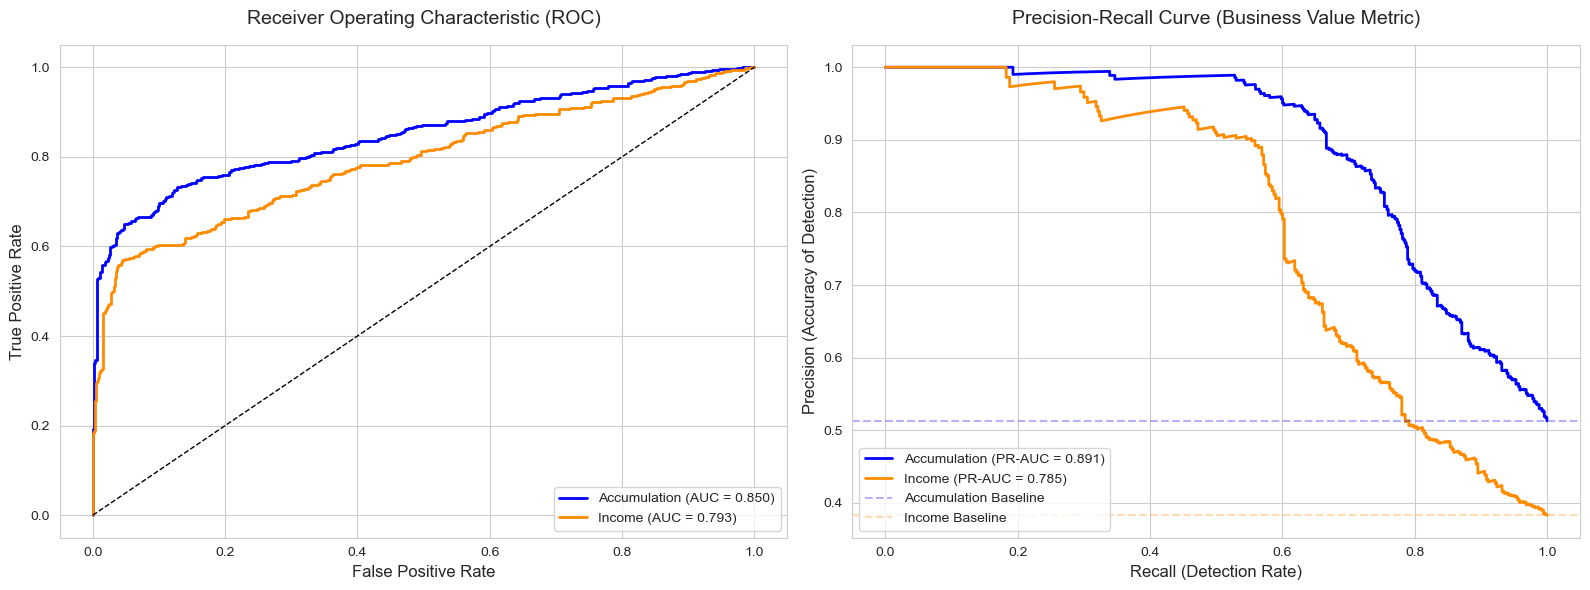

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc

print("--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---\n")

# Set aesthetic style
sns.set_style("whitegrid")

def plot_model_curves(y_true_acc, y_prob_acc, y_true_inc, y_prob_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. ROC Curve ---
    fpr_acc, tpr_acc, _ = roc_curve(y_true_acc, y_prob_acc)
    fpr_inc, tpr_inc, _ = roc_curve(y_true_inc, y_prob_inc)
    
    axes[0].plot(fpr_acc, tpr_acc, label=f'Accumulation (AUC = {auc(fpr_acc, tpr_acc):.3f})', color='blue', lw=2)
    axes[0].plot(fpr_inc, tpr_inc, label=f'Income (AUC = {auc(fpr_inc, tpr_inc):.3f})', color='darkorange', lw=2)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].legend(loc='lower right', frameon=True)
    
    # --- 2. Precision-Recall Curve ---
    # PR Curves are much more important for imbalanced targets (like the Income class)
    prec_acc, rec_acc, _ = precision_recall_curve(y_true_acc, y_prob_acc)
    prec_inc, rec_inc, _ = precision_recall_curve(y_true_inc, y_prob_inc)
    
    # Calculate baseline (random guessing) for PR curves
    baseline_acc = sum(y_true_acc) / len(y_true_acc)
    baseline_inc = sum(y_true_inc) / len(y_true_inc)
    
    axes[1].plot(rec_acc, prec_acc, label=f'Accumulation (PR-AUC = {auc(rec_acc, prec_acc):.3f})', color='blue', lw=2)
    axes[1].plot(rec_inc, prec_inc, label=f'Income (PR-AUC = {auc(rec_inc, prec_inc):.3f})', color='darkorange', lw=2)
    axes[1].axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.3, label='Accumulation Baseline')
    axes[1].axhline(y=baseline_inc, color='darkorange', linestyle='--', alpha=0.3, label='Income Baseline')
    axes[1].set_title('Precision-Recall Curve (Business Value Metric)', fontsize=14, pad=15)
    axes[1].set_xlabel('Recall (Detection Rate)', fontsize=12)
    axes[1].set_ylabel('Precision (Accuracy of Detection)', fontsize=12)
    axes[1].legend(loc='lower left', frameon=True)
    
    plt.tight_layout()
    plt.show()

# Pull fresh probabilities from the trained model so this cell is self-contained.
# Shows TEST-set curves (out-of-sample) - more honest than val.
p_acc_v, p_inc_v, y_acc_v, y_inc_v = get_raw_probs(model, test_loader)
plot_model_curves(y_acc_v, p_acc_v, y_inc_v, p_inc_v)

Running ablation

Epoch 000 | Loss: 1.4559 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1551 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.892/0.713
Epoch 020 | Loss: 1.1389 | ROC-AUC (Acc/Inc): 0.858/0.732 | PR-AUC (Acc/Inc): 0.895/0.712
Epoch 030 | Loss: 1.1234 | ROC-AUC (Acc/Inc): 0.859/0.740 | PR-AUC (Acc/Inc): 0.895/0.718
Epoch 040 | Loss: 1.1114 | ROC-AUC (Acc/Inc): 0.863/0.745 | PR-AUC (Acc/Inc): 0.899/0.721
Epoch 050 | Loss: 1.0948 | ROC-AUC (Acc/Inc): 0.862/0.743 | PR-AUC (Acc/Inc): 0.897/0.721
Epoch 060 | Loss: 1.0944 | ROC-AUC (Acc/Inc): 0.865/0.748 | PR-AUC (Acc/Inc): 0.900/0.722
Epoch 070 | Loss: 1.0843 | ROC-AUC (Acc/Inc): 0.864/0.739 | PR-AUC (Acc/Inc): 0.900/0.721

Early stopping triggered at epoch 78. Restoring best weights.
Epoch 000 | Loss: 1.4578 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1558 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.892/0.713
Epoch 020 | Loss: 1

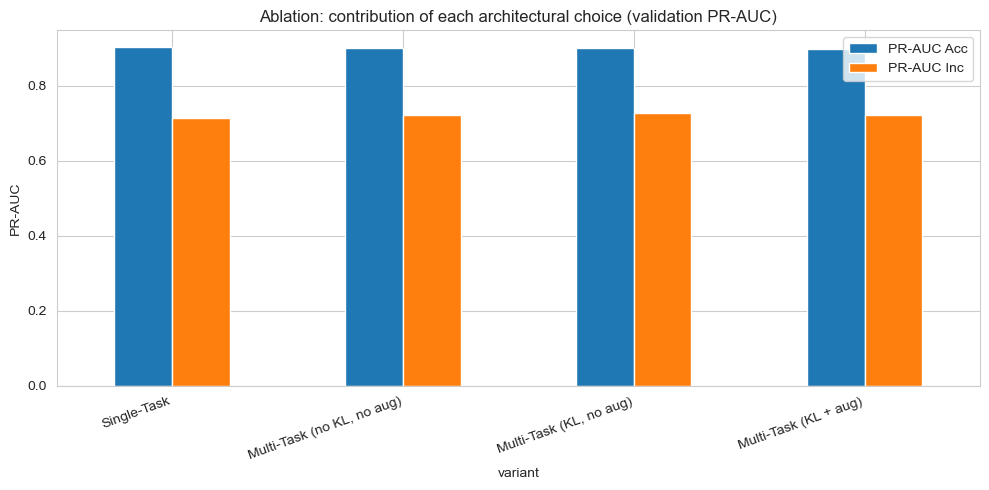

In [41]:
import copy
import torch.nn.functional as F
from dataclasses import dataclass
from sklearn.metrics import average_precision_score, roc_auc_score

@dataclass
class Variant:
    name: str
    multi_task: bool
    use_kl: bool
    use_augment: bool

variants = [
    Variant('Single-Task',                False, False, False),
    Variant('Multi-Task (no KL, no aug)',  True,  False, False),
    Variant('Multi-Task (KL, no aug)',     True,  True,  False),
    Variant('Multi-Task (KL + aug)',       True,  True,  True),
]

def train_single_head(in_dim, tr_ld, val_ld, pos_weight, target_idx, epochs=40,
                      seed=42):
    """
    target_idx: 0 -> Income, 1 -> Accumulation
    Returns validation probabilities (numpy).
    """
    torch.manual_seed(seed)
    m = SingleTaskMLP(in_dim=in_dim)
    opt = optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)

    for _ in range(epochs):
        m.train()
        for X_batch, y_inc_b, y_acc_b in tr_ld:
            targets = y_inc_b if target_idx == 0 else y_acc_b
            opt.zero_grad()
            logits = m(X_batch)
            loss = F.binary_cross_entropy_with_logits(logits, targets,
                                                      pos_weight=pos_weight)
            loss.backward()
            opt.step()

    m.eval()
    probs = []
    with torch.no_grad():
        for X_batch, _, _ in val_ld:
            probs.extend(torch.sigmoid(m(X_batch)).numpy())
    return np.array(probs)


def run_variant(v: Variant, seed: int = 42):
    torch.manual_seed(seed)
    tr_ds = FinancialNeedsDataset(X_train, y_train, augment=v.use_augment,
                                   noise_std=0.05, continuous_mask=continuous_mask)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)

    ya = y_val['AccumulationInvestment'].values
    yi = y_val['IncomeInvestment'].values

    if v.multi_task:
        m = MultiTaskNeedsMLP(in_dim=len(feature_cols))
        opt = optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
        lam = 0.15 if v.use_kl else 0.0
        m, _ = train_multitask_model(m, tr_ld, val_loader, opt,
                                      w_a, w_i, joint_prior,
                                      epochs=100, patience=15, lam=lam)
        pa, pi, _, _ = get_raw_probs(m, val_loader)
    else:
        # Two separate single-task models, each with full capacity of one
        # multi-task branch (same SingleTaskMLP class from cell 3)
        pa = train_single_head(len(feature_cols), tr_ld, val_loader,
                               w_a, target_idx=1, seed=seed)
        pi = train_single_head(len(feature_cols), tr_ld, val_loader,
                               w_i, target_idx=0, seed=seed)

    return {
        'variant': v.name,
        'PR-AUC Acc':  average_precision_score(ya, pa),
        'PR-AUC Inc':  average_precision_score(yi, pi),
        'ROC-AUC Acc': roc_auc_score(ya, pa),
        'ROC-AUC Inc': roc_auc_score(yi, pi),
    }

print("Running ablation\n")
results = [run_variant(v) for v in variants]
abl_df = pd.DataFrame(results).set_index('variant').round(4)
print(abl_df)

abl_df[['PR-AUC Acc', 'PR-AUC Inc']].plot(kind='bar', figsize=(10, 5))
plt.title('Ablation: contribution of each architectural choice (validation PR-AUC)')
plt.ylabel('PR-AUC')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


SHAP — Accumulation head: shap_values shape = (200, 20)


/var/folders/hs/9m7zchzx6gb534k85g2dfmnw0000gn/T/ipykernel_41149/2584907084.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


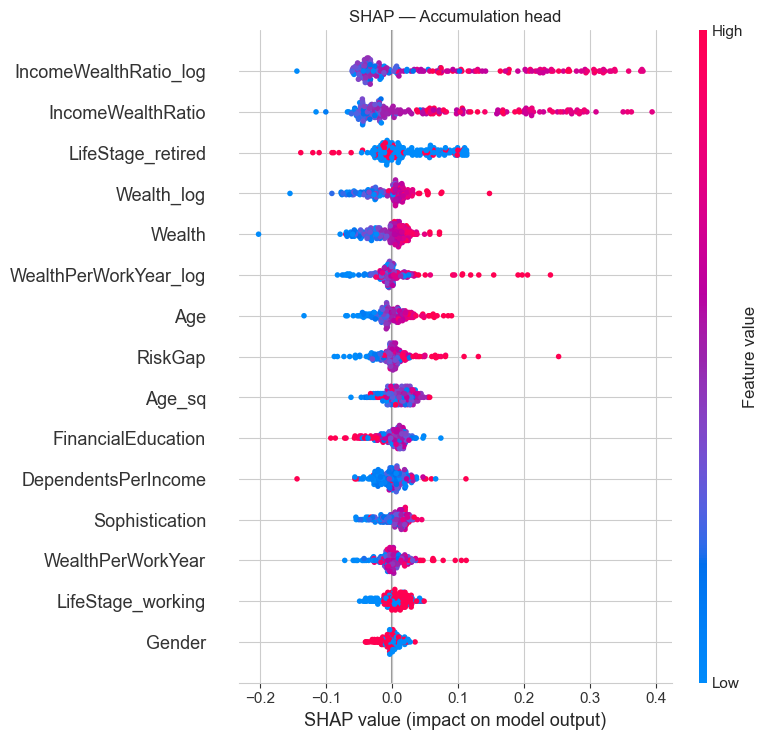

SHAP — Income head: shap_values shape = (200, 20)


/var/folders/hs/9m7zchzx6gb534k85g2dfmnw0000gn/T/ipykernel_41149/2584907084.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


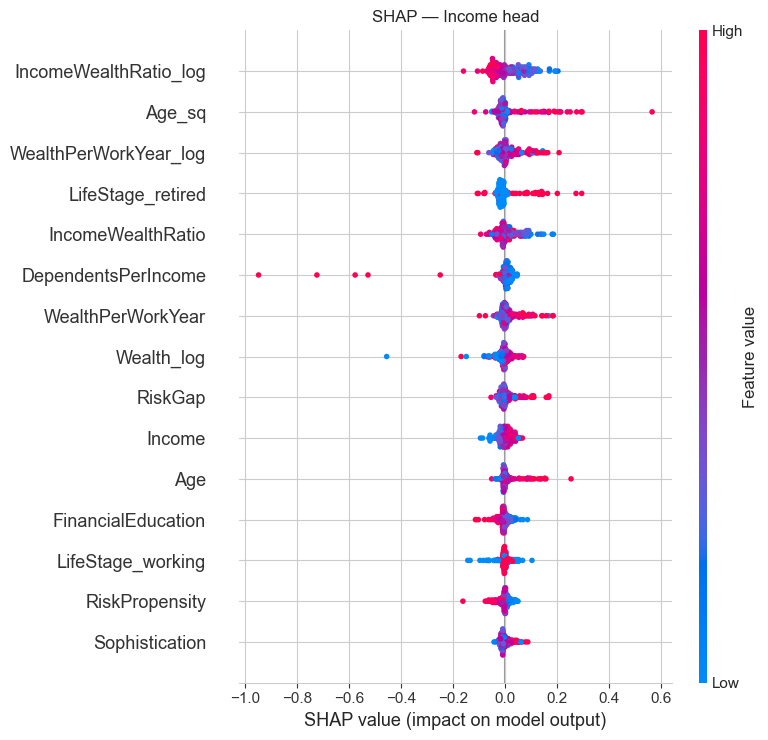

In [42]:
import shap
import numpy as np

# Wrap each head so DeepExplainer sees a single-output model
class HeadWrapper(torch.nn.Module):
    def __init__(self, base, head_name):
        super().__init__()
        self.base = base
        self.head_name = head_name  # 'accum' or 'income'
    def forward(self, x):
        la, li = self.base(x)
        out = la if self.head_name == 'accum' else li
        return torch.sigmoid(out).unsqueeze(-1)   # shape [batch, 1]

model.eval()

# Background sample (DeepExplainer baseline)
rng = np.random.RandomState(0)
bg_idx = rng.choice(len(X_train), size=100, replace=False)
bg_tensor = torch.tensor(X_train.values[bg_idx], dtype=torch.float32)

# Test subset to explain
n_explain = 200
test_sample = torch.tensor(X_test.values[:n_explain], dtype=torch.float32)
X_test_np = X_test.values[:n_explain]


def explain_head(head_name: str, title: str):
    wrapper = HeadWrapper(model, head_name)
    expl = shap.DeepExplainer(wrapper, bg_tensor)
    sv = expl.shap_values(test_sample, check_additivity=False)

    # Normalize SHAP output to 2D array [n_samples, n_features]
    # Different SHAP versions return list[ndarray] OR ndarray (2D or 3D)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[-1] == 1:
        sv = sv.squeeze(-1)              # drop trailing output dim
    assert sv.shape == (n_explain, len(feature_cols)), (
        f"Unexpected SHAP shape {sv.shape}, expected ({n_explain}, {len(feature_cols)})"
    )
    print(f"{title}: shap_values shape = {sv.shape}")

    shap.summary_plot(
        sv,
        X_test_np,
        feature_names=feature_cols,
        show=False,
        plot_type='dot',
        max_display=15,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


explain_head('accum',  'SHAP \u2014 Accumulation head')
explain_head('income', 'SHAP \u2014 Income head')


## Permutation importance (model-agnostic)

SHAP is powerful but tree-specific explainers are faster and NN-specific ones
(DeepExplainer) can be version-fragile. Permutation importance complements it:
- **Model-agnostic** — works on any `.predict`/`.predict_proba`-like interface
- **Measures what actually matters at inference** — drop in PR-AUC when a
  column is shuffled on the test set
- Directly comparable across models (e.g., vs. the RF baseline)

We do it manually because our model returns a tuple `(logits_acc, logits_inc)`
and sklearn's `permutation_importance` expects a single output. Doing it by
hand also lets us report per-head importance separately.


Computing permutation importance on the TEST set (~30s)...
Baseline PR-AUC  |  Accumulation: 0.8911   Income: 0.7856


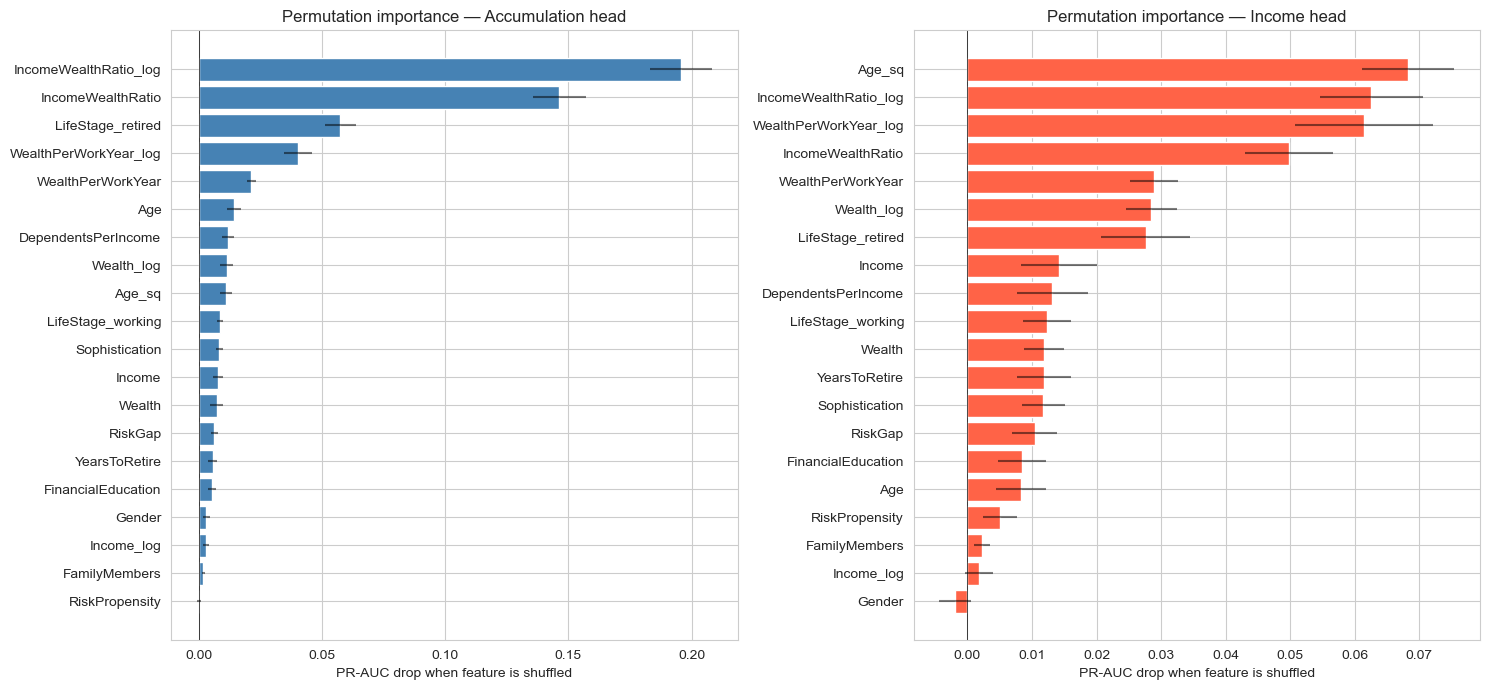


Accumulation head, top 5 drivers:
              feature  mean_drop  std_drop
IncomeWealthRatio_log   0.195705  0.012449
    IncomeWealthRatio   0.146234  0.010714
    LifeStage_retired   0.057375  0.006281
WealthPerWorkYear_log   0.040264  0.005571
    WealthPerWorkYear   0.021327  0.001863

Income head, top 5 drivers:
              feature  mean_drop  std_drop
               Age_sq   0.068280  0.007128
IncomeWealthRatio_log   0.062587  0.007983
WealthPerWorkYear_log   0.061436  0.010733
    IncomeWealthRatio   0.049825  0.006778
    WealthPerWorkYear   0.028968  0.003711

Features with drop < 0.001 on BOTH heads (candidates for removal):
  (none found)


In [43]:
from sklearn.metrics import average_precision_score

def permutation_importance_nn(model, X, y_acc, y_inc, feature_names,
                               n_repeats=10, seed=42):
    """Permutation importance for the multi-task NN, per head."""
    rng = np.random.RandomState(seed)
    model.eval()

    # Baseline PR-AUC on unperturbed test set
    with torch.no_grad():
        la, li = model(torch.tensor(X.values, dtype=torch.float32))
        base_pa = torch.sigmoid(la).numpy()
        base_pi = torch.sigmoid(li).numpy()
    base_ap_acc = average_precision_score(y_acc, base_pa)
    base_ap_inc = average_precision_score(y_inc, base_pi)

    imp_acc = {f: [] for f in feature_names}
    imp_inc = {f: [] for f in feature_names}

    X_np = X.values.copy()
    for col_idx, feat in enumerate(feature_names):
        original = X_np[:, col_idx].copy()
        for _ in range(n_repeats):
            X_perm = X_np.copy()
            rng.shuffle(X_perm[:, col_idx])
            with torch.no_grad():
                la, li = model(torch.tensor(X_perm, dtype=torch.float32))
                pa_p = torch.sigmoid(la).numpy()
                pi_p = torch.sigmoid(li).numpy()
            imp_acc[feat].append(base_ap_acc - average_precision_score(y_acc, pa_p))
            imp_inc[feat].append(base_ap_inc - average_precision_score(y_inc, pi_p))
        X_np[:, col_idx] = original

    def _summarize(imp_dict):
        return pd.DataFrame({
            'feature': list(imp_dict.keys()),
            'mean_drop': [np.mean(v) for v in imp_dict.values()],
            'std_drop':  [np.std(v)  for v in imp_dict.values()],
        }).sort_values('mean_drop', ascending=False)

    return _summarize(imp_acc), _summarize(imp_inc), base_ap_acc, base_ap_inc


print("Computing permutation importance on the TEST set (~30s)...")
y_acc_te_arr = y_test['AccumulationInvestment'].values
y_inc_te_arr = y_test['IncomeInvestment'].values
perm_acc, perm_inc, base_acc, base_inc = permutation_importance_nn(
    model, X_test, y_acc_te_arr, y_inc_te_arr, feature_cols, n_repeats=10,
)

print(f"Baseline PR-AUC  |  Accumulation: {base_acc:.4f}   Income: {base_inc:.4f}")

# Visualize side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, df, title, color in [
    (axes[0], perm_acc, 'Accumulation head', 'steelblue'),
    (axes[1], perm_inc, 'Income head',       'tomato'),
]:
    df_sorted = df.sort_values('mean_drop', ascending=True)
    ax.barh(df_sorted['feature'], df_sorted['mean_drop'],
            xerr=df_sorted['std_drop'], color=color,
            error_kw={'ecolor': 'black', 'alpha': 0.5})
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f'Permutation importance — {title}')
    ax.set_xlabel('PR-AUC drop when feature is shuffled')
plt.tight_layout()
plt.show()

print("\nAccumulation head, top 5 drivers:")
print(perm_acc.head().to_string(index=False))
print("\nIncome head, top 5 drivers:")
print(perm_inc.head().to_string(index=False))

# Identify dead-weight features: negative OR near-zero on BOTH heads
dead_threshold = 0.001  # a drop < 0.1% PR-AUC is noise
dead_features = []
for f in feature_cols:
    drop_acc = perm_acc[perm_acc['feature'] == f]['mean_drop'].values[0]
    drop_inc = perm_inc[perm_inc['feature'] == f]['mean_drop'].values[0]
    if drop_acc < dead_threshold and drop_inc < dead_threshold:
        dead_features.append(f)

print(f"\nFeatures with drop < {dead_threshold} on BOTH heads (candidates for removal):")
for f in dead_features:
    da = perm_acc[perm_acc['feature'] == f]['mean_drop'].values[0]
    di = perm_inc[perm_inc['feature'] == f]['mean_drop'].values[0]
    print(f"  {f:28s}  Acc drop: {da:+.4f}   Inc drop: {di:+.4f}")

if not dead_features:
    print("  (none found)")

## Optional retrain without dead-weight features

If permutation importance flagged features that add no signal on either head,
we can retrain the model without them. This is strictly an ablation — it may
or may not improve test PR-AUC, but it simplifies the model and the report.

Set `RETRAIN_WITHOUT_DEAD = True` to execute this ablation.


In [44]:
RETRAIN_WITHOUT_DEAD = True  # set False to skip this ablation

if RETRAIN_WITHOUT_DEAD and dead_features:
    keep_cols = [f for f in feature_cols if f not in dead_features]
    print(f"Retraining without {len(dead_features)} dead features.")
    print(f"  Original: {len(feature_cols)} features  ->  Slim: {len(keep_cols)} features")

    # Slim matrices
    X_train_slim = X_train[keep_cols]
    X_val_slim   = X_val[keep_cols]
    X_test_slim  = X_test[keep_cols]

    # Rebuild the continuous mask for the slim feature set
    discrete_features = {'Gender', 'FamilyMembers', 'FinancialEducation',
                          'LifeStage_working', 'LifeStage_retired'}
    _ = [c not in discrete_features for c in keep_cols]  # unused: augment=False anyway

    # Slim datasets + loaders (same batch size as tuned)
    tr_slim = FinancialNeedsDataset(X_train_slim, y_train, augment=False)
    val_slim  = FinancialNeedsDataset(X_val_slim,   y_val,   augment=False)
    test_slim = FinancialNeedsDataset(X_test_slim,  y_test,  augment=False)
    tr_ld_slim  = DataLoader(tr_slim,  batch_size=BEST['batch_size'], shuffle=True)
    val_ld_slim = DataLoader(val_slim, batch_size=256, shuffle=False)
    test_ld_slim = DataLoader(test_slim, batch_size=256, shuffle=False)

    # Same tuned architecture, new input dim
    torch.manual_seed(42)
    model_slim = MultiTaskNeedsMLP(in_dim=len(keep_cols),
                                    trunk=(BEST['trunk_w1'], BEST['trunk_w2']),
                                    head=(BEST['head_w'],),
                                    p=BEST['dropout'])
    opt_slim = optim.AdamW(model_slim.parameters(),
                            lr=BEST['lr'], weight_decay=BEST['weight_decay'])

    model_slim, _ = train_multitask_model(
        model_slim, tr_ld_slim, val_ld_slim, opt_slim,
        w_a, w_i, joint_prior,
        epochs=150, patience=20, lam=BEST['lam'],
    )

    # Evaluate on TEST
    pa_s, pi_s, ya_s, yi_s = get_raw_probs(model_slim, test_ld_slim)

    print("\n=== SLIM MODEL (test) vs FULL MODEL (test) ===")
    for name, ya, yi, pa, pi in [
        ('FULL', y_acc_te, y_inc_te, p_acc_te, p_inc_te),
        ('SLIM', ya_s, yi_s, pa_s, pi_s),
    ]:
        print(f"\n{name} model:")
        print(f"  Accum  ROC-AUC: {roc_auc_score(ya, pa):.4f}   "
              f"PR-AUC: {average_precision_score(ya, pa):.4f}")
        print(f"  Income ROC-AUC: {roc_auc_score(yi, pi):.4f}   "
              f"PR-AUC: {average_precision_score(yi, pi):.4f}")
    print("\nIf SLIM matches or beats FULL, prefer it: fewer features, same signal.")
elif not dead_features:
    print("No dead features identified — slim model not needed.")
else:
    print("Skipped slim retrain (RETRAIN_WITHOUT_DEAD = False).")

No dead features identified — slim model not needed.


All models evaluated on 1000 shared test clients.

UNIFIED TEST-SET COMPARISON (all models, same clients, same labels)
        Model  ROC-AUC Accum  PR-AUC  Accum  Brier   Accum  F1@thr  Accum  ROC-AUC Incom  PR-AUC  Incom  Brier   Incom  F1@thr  Incom
Decision Tree         0.8745         0.9087         0.1269         0.8423         0.8115         0.8125         0.1474         0.7395
Random Forest         0.8759         0.9130         0.1187         0.8383         0.7958         0.8055         0.1456         0.7348
Multi-Task NN         0.8504         0.8911         0.1486         0.7891         0.7926         0.7856         0.1589         0.6932

Brier score: lower = better calibrated probabilities.
F1@thr: each model uses its own F1-optimal threshold (fair to each).



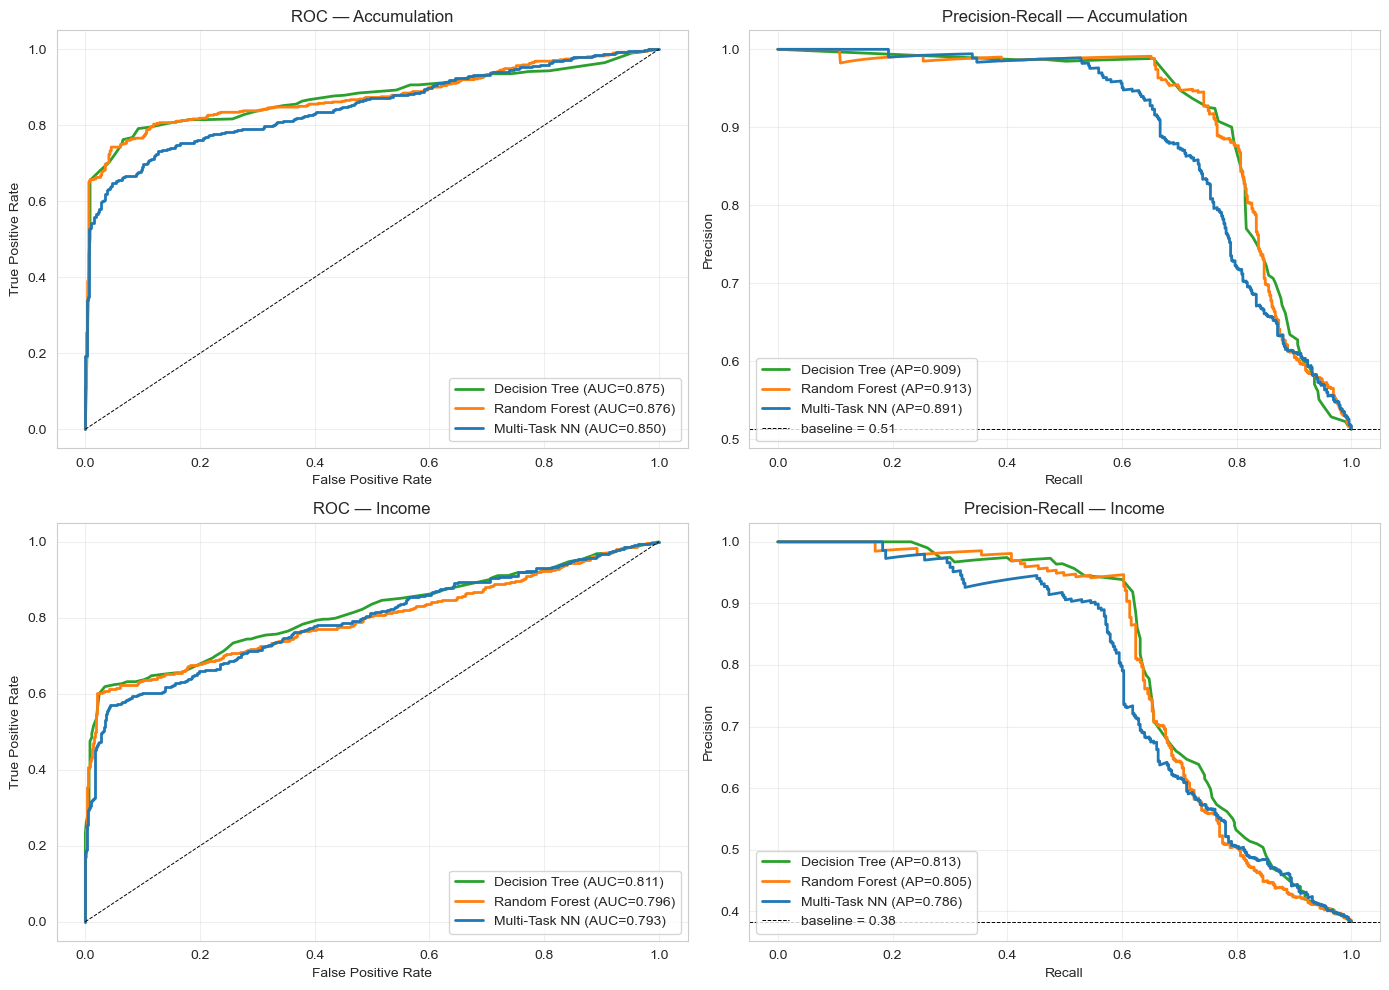

Saved -> compare_preds/comparison_table.csv  +  comparison_curves.png


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss, roc_curve, precision_recall_curve,
                              f1_score)
 
# ---- Load ----
y_acc = np.load('compare_preds/y_acc_test.npy')
y_inc = np.load('compare_preds/y_inc_test.npy')
 
preds = {
    'Decision Tree' : {'acc': np.load('compare_preds/dt_p_acc_test.npy'),
                       'inc': np.load('compare_preds/dt_p_inc_test.npy')},
    'Random Forest' : {'acc': np.load('compare_preds/rf_p_acc_test.npy'),
                       'inc': np.load('compare_preds/rf_p_inc_test.npy')},
    'Multi-Task NN' : {'acc': np.load('compare_preds/mtl_p_acc_test.npy'),
                       'inc': np.load('compare_preds/mtl_p_inc_test.npy')},
}
 
# Sanity check — all predictions must be on the same number of test rows.
for name, p in preds.items():
    assert len(p['acc']) == len(y_acc), f"{name}: accum length mismatch"
    assert len(p['inc']) == len(y_inc), f"{name}: income length mismatch"
print(f"All models evaluated on {len(y_acc)} shared test clients.\n")
 
# ---- Helper: best F1 threshold, model-specific (honest comparison) ----
def best_f1(y, p, grid=np.linspace(0.05, 0.95, 181)):
    scores = [f1_score(y, p > t) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i])
 
# ---- Build the unified table ----
rows = []
for name, p in preds.items():
    thr_a, f1_a = best_f1(y_acc, p['acc'])
    thr_i, f1_i = best_f1(y_inc, p['inc'])
    rows.append({
        'Model':     name,
        'ROC-AUC Accum': round(roc_auc_score(y_acc, p['acc']), 4),
        'PR-AUC  Accum': round(average_precision_score(y_acc, p['acc']), 4),
        'Brier   Accum': round(brier_score_loss(y_acc, p['acc']), 4),
        'F1@thr  Accum': round(f1_a, 4),
        'ROC-AUC Incom': round(roc_auc_score(y_inc, p['inc']), 4),
        'PR-AUC  Incom': round(average_precision_score(y_inc, p['inc']), 4),
        'Brier   Incom': round(brier_score_loss(y_inc, p['inc']), 4),
        'F1@thr  Incom': round(f1_i, 4),
    })
cmp_df = pd.DataFrame(rows)
 
print("=" * 90)
print("UNIFIED TEST-SET COMPARISON (all models, same clients, same labels)")
print("=" * 90)
print(cmp_df.to_string(index=False))
print("\nBrier score: lower = better calibrated probabilities.")
print("F1@thr: each model uses its own F1-optimal threshold (fair to each).\n")
 
# Save for the deck
cmp_df.to_csv('compare_preds/comparison_table.csv', index=False)
 
# ---- ROC + PR curves, side-by-side per head ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'Decision Tree': 'tab:green',
          'Random Forest': 'tab:orange',
          'Multi-Task NN': 'tab:blue'}
 
for row, head in enumerate(['acc', 'inc']):
    y = y_acc if head == 'acc' else y_inc
    head_name = 'Accumulation' if head == 'acc' else 'Income'
 
    # ROC
    for name, p in preds.items():
        fpr, tpr, _ = roc_curve(y, p[head])
        auc = roc_auc_score(y, p[head])
        axes[row, 0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                          color=colors[name], lw=2)
    axes[row, 0].plot([0, 1], [0, 1], 'k--', lw=0.7)
    axes[row, 0].set_title(f'ROC — {head_name}')
    axes[row, 0].set_xlabel('False Positive Rate')
    axes[row, 0].set_ylabel('True Positive Rate')
    axes[row, 0].legend(loc='lower right')
    axes[row, 0].grid(alpha=0.3)
 
    # PR
    base = y.mean()
    for name, p in preds.items():
        pr, rc, _ = precision_recall_curve(y, p[head])
        ap = average_precision_score(y, p[head])
        axes[row, 1].plot(rc, pr, label=f'{name} (AP={ap:.3f})',
                          color=colors[name], lw=2)
    axes[row, 1].axhline(base, color='k', ls='--', lw=0.7,
                         label=f'baseline = {base:.2f}')
    axes[row, 1].set_title(f'Precision-Recall — {head_name}')
    axes[row, 1].set_xlabel('Recall')
    axes[row, 1].set_ylabel('Precision')
    axes[row, 1].legend(loc='lower left')
    axes[row, 1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('compare_preds/comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> compare_preds/comparison_table.csv  +  comparison_curves.png")

## Conceptual note on target labels

`IncomeInvestment` and `AccumulationInvestment` are **proxy labels derived from
observed holdings**, not direct measurements of client needs. They follow the
revealed-preference scheme described in the business case: a client is treated
as having a need if their (professionally vetted) advisor has matched them with
a product satisfying that need.

Two consequences of this we deliberately account for in the model:

1. **Label noise.** The model can only be as good as the advisor process it
   clones. Part of the motivation for the KL consistency term is to anchor the
   model on the *aggregate* behaviour of the advisor pool rather than
   overfitting individual calls.
2. **Selection bias.** Clients without a matching product have `y = 0`, but
   some of them may in fact have the need (it just wasn't acted on). This
   biases Recall downward and is a reason to take precision-oriented metrics
   with care. A production deployment should periodically re-label against
   post-recommendation acceptance data.